# House Prices (Ames) —  Análise Exploratória de Dados

Competição de Machine Learning para prever o valor de venda de imóveis em Ames, Iowa (EUA).  
**Métrica oficial:** RMSLE. **Objetivo:** superar o baseline do professor (RMSLE < 0.17543).

---

### Estrutura deste notebook

1. Carga dos dados  
2. Visão geral (shape, tipos, estatísticas descritivas)  
3. Variável alvo `SalePrice` — distribuição e assimetria  
4. Correlações com variáveis numéricas (heatmap + scatter)  
5. Variáveis categóricas relevantes (boxplots)  
6. Valores ausentes — mapa e significado no contexto de negócio

## Imports e Configuração

Todas as bibliotecas utilizadas nos notebooks estão carregadas nesta célula.

In [5]:
# === Manipulacao e visualizacao ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# === Modelagem (sklearn) ===
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.model_selection import (
    train_test_split, KFold, cross_validate, RandomizedSearchCV,
)
from sklearn.metrics import (
    mean_squared_log_error, mean_absolute_error, r2_score, make_scorer,
)

# === Utilidades ===
import time, joblib, os
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100
RNG = 42  # seed fixa para reprodutibilidade

print('Imports OK.')

Imports OK.


---
# Análise Exploratória de Dados

Investigamos o dataset *House Prices* (Ames, Iowa) para compreender a estrutura dos dados
antes de qualquer modelagem. Os principais focos foram:

- Distribuição do alvo `SalePrice` — assimetria positiva que motiva o uso de `log1p` na modelagem.
- Variáveis mais correlacionadas com o preço (`OverallQual`, `GrLivArea`, `GarageCars`, `TotalBsmtSF`).
- Variáveis categóricas relevantes (`Neighborhood`, `KitchenQual`, `ExterQual`).
- Mapa de valores ausentes e seus significados no contexto do negócio
  (ex.: `PoolQC = NaN` indica ausência de piscina, não dado perdido).

## 1) Carga dos Dados

In [6]:
df = pd.read_csv('treino.csv')
print(f'Shape: {df.shape}')
display(df.head())

Shape: (1168, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,255,20,RL,70.0,8400,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,145000
1,1067,60,RL,59.0,7837,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2009,WD,Normal,178000
2,639,30,RL,67.0,8777,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,5,2008,WD,Normal,85000
3,800,50,RL,60.0,7200,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,6,2007,WD,Normal,175000
4,381,50,RL,50.0,5000,Pave,Pave,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,127000


## 2) Visão Geral

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1168 entries, 0 to 1167
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1168 non-null   int64  
 1   MSSubClass     1168 non-null   int64  
 2   MSZoning       1168 non-null   object 
 3   LotFrontage    951 non-null    float64
 4   LotArea        1168 non-null   int64  
 5   Street         1168 non-null   object 
 6   Alley          74 non-null     object 
 7   LotShape       1168 non-null   object 
 8   LandContour    1168 non-null   object 
 9   Utilities      1168 non-null   object 
 10  LotConfig      1168 non-null   object 
 11  LandSlope      1168 non-null   object 
 12  Neighborhood   1168 non-null   object 
 13  Condition1     1168 non-null   object 
 14  Condition2     1168 non-null   object 
 15  BldgType       1168 non-null   object 
 16  HouseStyle     1168 non-null   object 
 17  OverallQual    1168 non-null   int64  
 18  OverallC

In [8]:
print('=== ESTATISTICAS DESCRITIVAS (Numericas) ===')
display(df.describe().T.style.background_gradient(cmap='Blues', subset=['mean','std']))

=== ESTATISTICAS DESCRITIVAS (Numericas) ===


,count,mean,std,min,25%,50%,75%,max
Id,1168.000000,730.904966,425.369088,1.000000,360.750000,732.500000,1101.750000,1460.000000
MSSubClass,1168.000000,56.849315,42.531862,20.000000,20.000000,50.000000,70.000000,190.000000
LotFrontage,951.000000,70.343849,24.897021,21.000000,59.000000,70.000000,80.000000,313.000000
LotArea,1168.000000,10689.642123,10759.366198,1300.000000,7587.250000,9600.000000,11700.000000,215245.000000
OverallQual,1168.000000,6.121575,1.367619,1.000000,5.000000,6.000000,7.000000,10.000000
OverallCond,1168.000000,5.584760,1.116062,1.000000,5.000000,5.000000,6.000000,9.000000
YearBuilt,1168.000000,1970.965753,30.675495,1872.000000,1953.000000,1972.000000,2001.000000,2010.000000
YearRemodAdd,1168.000000,1984.897260,20.733955,1950.000000,1966.000000,1994.000000,2004.000000,2010.000000
MasVnrArea,1162.000000,103.771945,173.032238,0.000000,0.000000,0.000000,166.000000,1378.000000
BsmtFinSF1,1168.000000,446.023973,459.070977,0.000000,0.000000,384.500000,721.000000,5644.000000


In [9]:
print('=== ESTATISTICAS DESCRITIVAS (Categoricas) ===')
display(df.describe(include=['object']).T)

=== ESTATISTICAS DESCRITIVAS (Categoricas) ===


,count,unique,top,freq
MSZoning,1168,5,RL,924
Street,1168,2,Pave,1164
Alley,74,2,Grvl,44
LotShape,1168,4,Reg,729
LandContour,1168,4,Lvl,1059
Utilities,1168,2,AllPub,1167
LotConfig,1168,5,Inside,822
LandSlope,1168,3,Gtl,1108
Neighborhood,1168,25,NAmes,181
Condition1,1168,9,Norm,1004


## 3) Variável Alvo — `SalePrice`

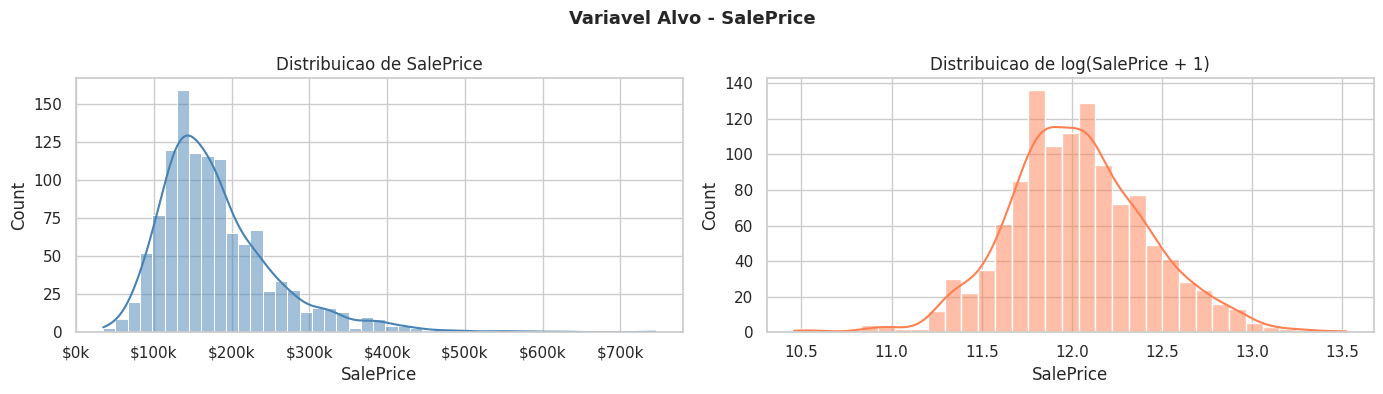

Skewness original : 1.7431
Skewness log+1    : 0.1249


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df['SalePrice'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribuicao de SalePrice')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

sns.histplot(np.log1p(df['SalePrice']), kde=True, ax=axes[1], color='coral')
axes[1].set_title('Distribuicao de log(SalePrice + 1)')

plt.suptitle('Variavel Alvo - SalePrice', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Skewness original : {df['SalePrice'].skew():.4f}")
print(f"Skewness log+1    : {np.log1p(df['SalePrice']).skew():.4f}")

## 4) Correlações com Variáveis Numéricas

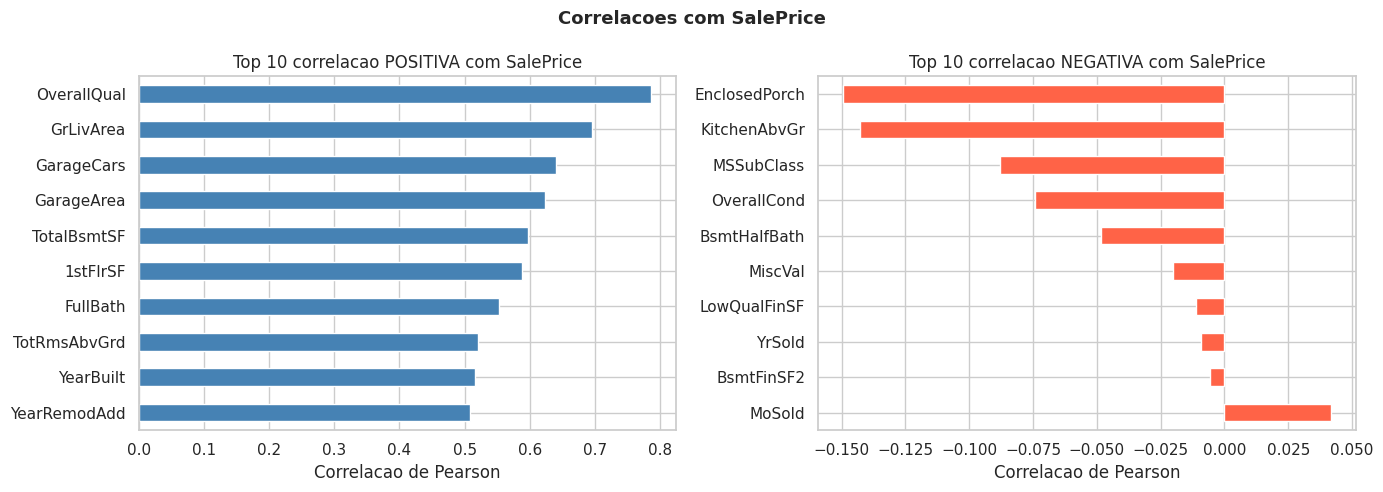

In [11]:
numeric_df = df.select_dtypes(include=[np.number]).drop(columns=['Id'])
corr_target = numeric_df.corr()['SalePrice'].drop('SalePrice').sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

corr_target.head(10).plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].invert_yaxis()
axes[0].set_title('Top 10 correlacao POSITIVA com SalePrice')
axes[0].set_xlabel('Correlacao de Pearson')

corr_target.tail(10).plot(kind='barh', ax=axes[1], color='tomato')
axes[1].set_title('Top 10 correlacao NEGATIVA com SalePrice')
axes[1].set_xlabel('Correlacao de Pearson')

plt.suptitle('Correlacoes com SalePrice', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

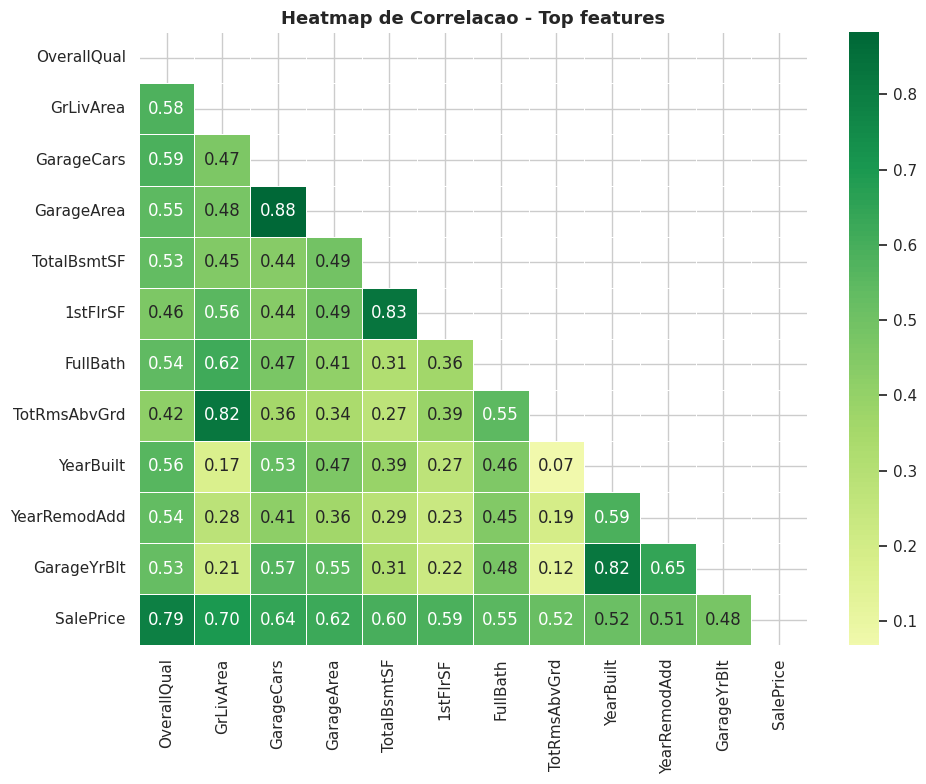

In [12]:
# Heatmap das 12 variaveis com maior correlacao
top_cols = corr_target.abs().nlargest(11).index.tolist() + ['SalePrice']
corr_matrix = numeric_df[top_cols].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, linewidths=0.5)
plt.title('Heatmap de Correlacao - Top features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

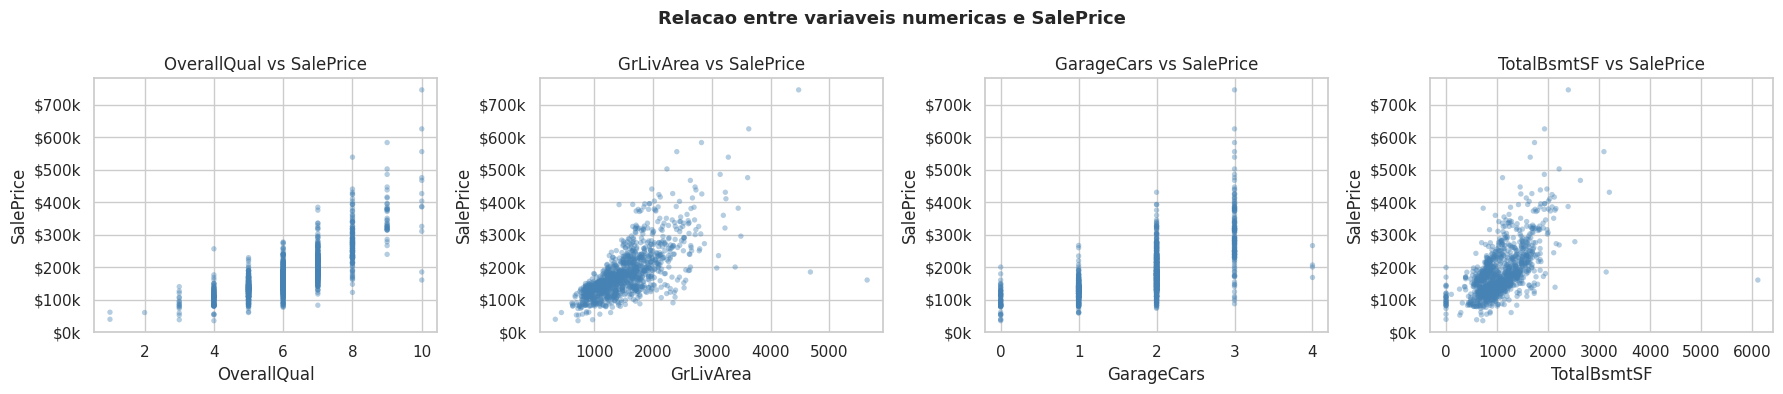

In [13]:
# Scatter das 4 variaveis numericas mais correlacionadas
top4 = ['OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF']
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, col in zip(axes, top4):
    ax.scatter(df[col], df['SalePrice'], alpha=0.4, color='steelblue', edgecolors='none', s=15)
    ax.set_xlabel(col)
    ax.set_ylabel('SalePrice')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
    ax.set_title(f'{col} vs SalePrice')

plt.suptitle('Relacao entre variaveis numericas e SalePrice', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5) Variáveis Categóricas

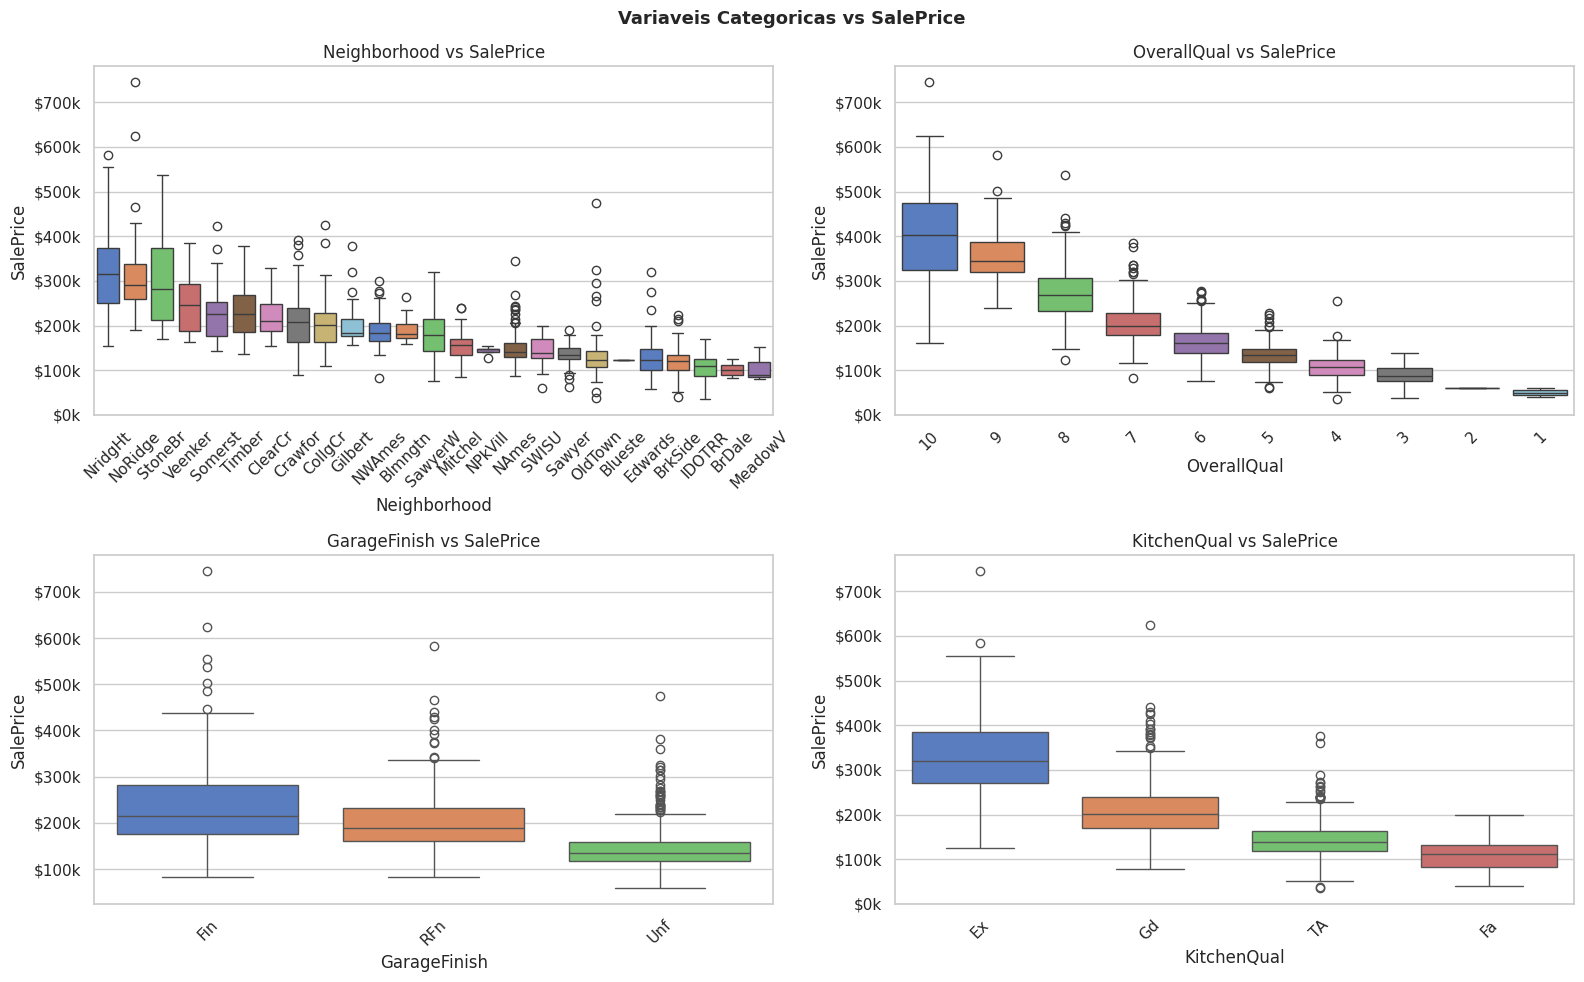

In [14]:
cat_cols = ['Neighborhood', 'OverallQual', 'GarageFinish', 'KitchenQual']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, col in zip(axes, cat_cols):
    order = df.groupby(col)['SalePrice'].median().sort_values(ascending=False).index
    sns.boxplot(data=df, x=col, y='SalePrice', order=order, ax=ax, palette='muted')
    ax.set_title(f'{col} vs SalePrice')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Variaveis Categoricas vs SalePrice', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 6) Valores Ausentes

,Total Nulos,Porcentagem (%)
PoolQC,1162,99.486301
MiscFeature,1122,96.061644
Alley,1094,93.664384
Fence,935,80.051370
MasVnrType,683,58.476027
FireplaceQu,547,46.832192
LotFrontage,217,18.578767
GarageType,64,5.479452
GarageYrBlt,64,5.479452
GarageFinish,64,5.479452


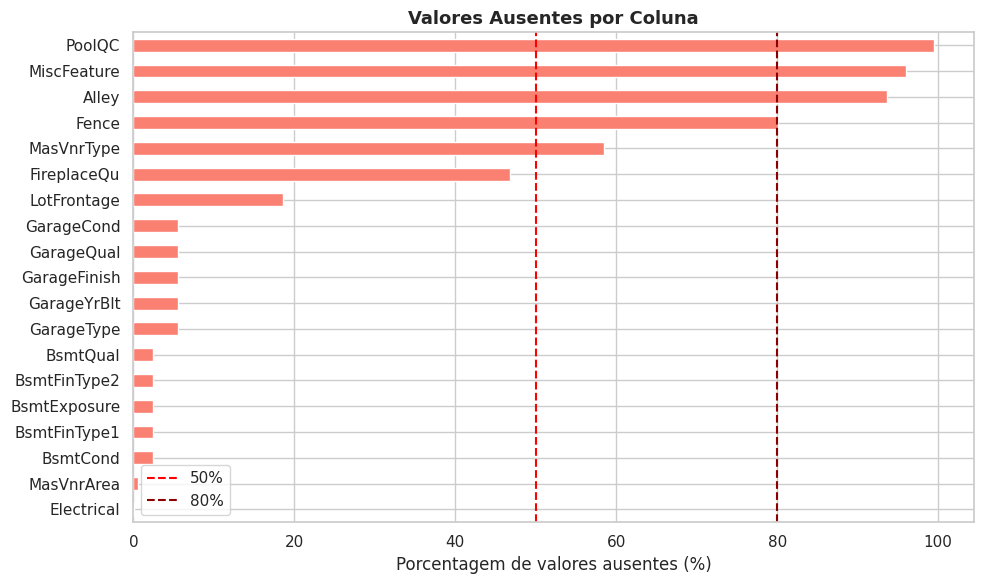

In [15]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({'Total Nulos': missing, 'Porcentagem (%)': missing_pct})
display(missing_df)

plt.figure(figsize=(10, 6))
missing_pct.sort_values(ascending=True).plot(kind='barh', color='salmon')
plt.axvline(x=50, color='red', linestyle='--', label='50%')
plt.axvline(x=80, color='darkred', linestyle='--', label='80%')
plt.xlabel('Porcentagem de valores ausentes (%)')
plt.title('Valores Ausentes por Coluna', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()